# Exploratory Data Analysis (EDA) - Prediksi Churn Pelanggan

**Dataset:** Sales and Marketing Customer Dataset  
**Tujuan:** Memahami karakteristik data, mengidentifikasi missing value, melihat distribusi target, dan menganalisis korelasi antar fitur numerik.

## 1. Load Data & Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Biar visualisasi lebih rapi
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

In [2]:
# Load dataset
df = pd.read_csv('../dataset/Sales - Marketing customer dataset.csv')
print(f'Dataset berhasil dimuat dengan {df.shape[0]} baris dan {df.shape[1]} kolom.')

Dataset berhasil dimuat dengan 15000 baris dan 30 kolom.


## 2. Menampilkan 5 Baris Pertama, Informasi Dataset, dan Statistik Deskriptif

In [3]:
# Menampilkan 5 baris pertama
df.head()

,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,...,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,...,2,1,4,BKash,3.0,1,12.39,87.680409,11,0


In [4]:
# Informasi dataset (tipe data, jumlah non-null, memory usage)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 15000 non-null  int64  
 1   gender                      14262 non-null  str    
 2   age                         13800 non-null  float64
 3   country                     15000 non-null  str    
 4   city                        15000 non-null  str    
 5   signup_date                 15000 non-null  str    
 6   last_purchase_date          15000 non-null  str    
 7   acquisition_channel         15000 non-null  str    
 8   device_type                 15000 non-null  str    
 9   subscription_type           15000 non-null  str    
 10  is_premium_user             15000 non-null  int64  
 11  total_visits                15000 non-null  int64  
 12  avg_session_time            15000 non-null  float64
 13  pages_per_session           15000 non-null

In [5]:
# Statistik deskriptif untuk fitur numerik
df.describe()

,customer_id,age,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,discount_used,support_tickets,refund_requested,delivery_delay_days,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
count,15000.000000,13800.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,13950.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,14298.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,17500.500000,35.203913,0.304467,15.000933,8.020805,4.002901,0.496278,0.251231,524.357397,60.080882,0.494467,1.995600,0.147667,2.981333,3.588754,4.968667,17.575238,1235.698200,6.975133,0.153200
std,4330.271354,10.334384,0.460197,3.892704,2.991499,1.479846,0.290108,0.144689,467.050070,24.746203,0.499986,1.421214,0.354781,1.720537,1.088703,3.155495,7.183437,657.521849,4.323443,0.360192
min,10001.000000,-4.000000,0.000000,3.000000,0.006095,0.007845,0.000000,0.000000,0.267291,0.071596,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,5.000000,0.368886,0.000000,0.000000
25%,13750.750000,28.000000,0.000000,12.000000,5.974555,2.989150,0.240000,0.130000,300.432074,43.032470,0.000000,1.000000,0.000000,2.000000,3.000000,2.000000,11.380000,741.301251,3.000000,0.000000
50%,17500.500000,35.000000,0.000000,15.000000,7.991907,3.996992,0.500000,0.250000,498.843859,60.108827,0.000000,2.000000,0.000000,3.000000,4.000000,5.000000,17.630000,1216.210685,7.000000,0.000000
75%,21250.250000,42.000000,1.000000,18.000000,10.059986,5.014406,0.750000,0.380000,702.396635,76.888445,1.000000,3.000000,0.000000,4.000000,4.000000,8.000000,23.770000,1677.860399,11.000000,0.000000
max,25000.000000,95.000000,1.000000,31.000000,19.123716,10.843172,1.000000,0.500000,15910.431879,154.554696,1.000000,9.000000,1.000000,11.000000,5.000000,10.000000,30.000000,3767.490455,14.000000,1.000000


In [6]:
# Statistik deskriptif untuk fitur kategorikal
df.describe(include='object')

C:\Users\HP\AppData\Local\Temp\ipykernel_14532\2322060811.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,gender,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,coupon_code,payment_method
count,14262,15000,15000,15000,15000,15000,15000,15000,8867,15000
unique,3,5,7,1000,800,5,3,2,3,5
top,Male,Germany,London,2024-09-20 00:00:00,2025-01-17 00:00:00,Organic,Tablet,Monthly,REF10,UPI
freq,6844,3072,2236,29,32,3055,5043,7666,2995,3105


**Insight:**
- Dataset terdiri dari 15.000 baris dan 30 kolom.
- Terdapat campuran tipe data: 10 kolom float64, 10 kolom int64, dan 10 kolom object.
- Beberapa kolom memiliki jumlah non-null yang lebih rendah dari total baris, menandakan adanya missing value.
- Dari statistik deskriptif, terlihat kolom `age` memiliki nilai minimum -4 yang kemungkinan merupakan data anomali/error.

## 3. Persentase Missing Value & Visualisasi

In [7]:
# ============================================================
# TUGAS 2: Hitung persentase missing value tiap kolom
# ------------------------------------------------------------
# isnull().sum() -> jumlah sel kosong per kolom
# dibagi total baris x100 -> persentase, lalu diurutkan dari terbesar
# ============================================================
missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df)) * 100

# Gabungkan jadi satu DataFrame biar gampang dibaca
missing_df = pd.DataFrame({
    'Jumlah Missing': missing_count,
    'Persentase (%)': missing_pct
}).sort_values(by='Persentase (%)', ascending=False)

print('=== Persentase Missing Value Semua Kolom ===')
print(missing_df)

=== Persentase Missing Value Semua Kolom ===
                            Jumlah Missing  Persentase (%)
coupon_code                           6133       40.886667
age                                   1200        8.000000
total_spent                           1050        7.000000
gender                                 738        4.920000
satisfaction_score                     702        4.680000
customer_id                              0        0.000000
last_purchase_date                       0        0.000000
acquisition_channel                      0        0.000000
device_type                              0        0.000000
subscription_type                        0        0.000000
is_premium_user                          0        0.000000
country                                  0        0.000000
city                                     0        0.000000
signup_date                              0        0.000000
pages_per_session                        0        0.000000
avg_session

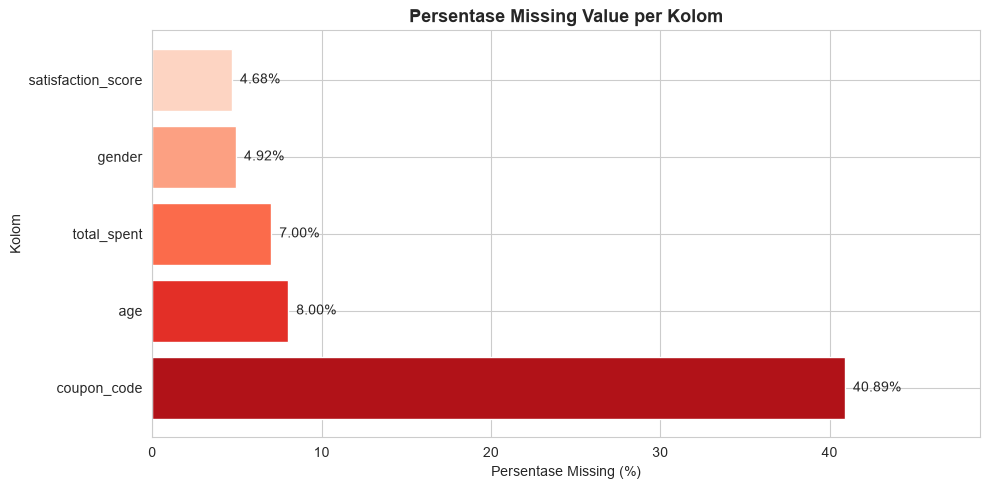

In [8]:
# Filter hanya kolom yang punya missing value > 0
missing_only = missing_df[missing_df['Jumlah Missing'] > 0].copy()
missing_only = missing_only.reset_index().rename(columns={'index': 'Kolom'})

# Visualisasi diagram batang
plt.figure(figsize=(10, 5))
bars = plt.barh(missing_only['Kolom'], missing_only['Persentase (%)'], color=sns.color_palette('Reds_r', len(missing_only)))

# Tambahin label persentase di ujung bar
for bar, pct in zip(bars, missing_only['Persentase (%)']):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{pct:.2f}%', va='center', fontsize=10)

plt.xlabel('Persentase Missing (%)')
plt.ylabel('Kolom')
plt.title('Persentase Missing Value per Kolom', fontsize=13, fontweight='bold')
plt.xlim(0, max(missing_only['Persentase (%)']) + 8)
plt.tight_layout()
plt.show()

**Insight:**
- Terdapat 5 kolom yang memiliki missing value dari total 30 kolom.
- `coupon_code` memiliki missing value tertinggi (~40.89%), yang wajar karena tidak semua pelanggan menggunakan kupon.
- Kolom `age` (~8%), `total_spent` (~7%), `gender` (~4.92%), dan `satisfaction_score` (~4.68%) juga memiliki data kosong yang perlu ditangani di tahap preprocessing.
- Strategi penanganan missing value akan dilakukan di tahap Data Preparation.

## 4. Distribusi Variabel Target (Churn)

In [9]:
# ============================================================
# TUGAS 3: Distribusi variabel target (churn)
# ------------------------------------------------------------
# Tujuan: cek apakah kelas seimbang. Hasil -> IMBALANCE (85% vs 15%).
# Ini jadi dasar keputusan: pakai stratify saat split & F1-score saat tuning.
# ============================================================
print('Distribusi kelas target (churn):')
print(df['churn'].value_counts())
print()
print('Persentase masing-masing kelas:')
print(df['churn'].value_counts(normalize=True).apply(lambda x: f'{x*100:.2f}%'))

Distribusi kelas target (churn):
churn
0    12702
1     2298
Name: count, dtype: int64

Persentase masing-masing kelas:
churn
0    84.68%
1    15.32%
Name: proportion, dtype: str


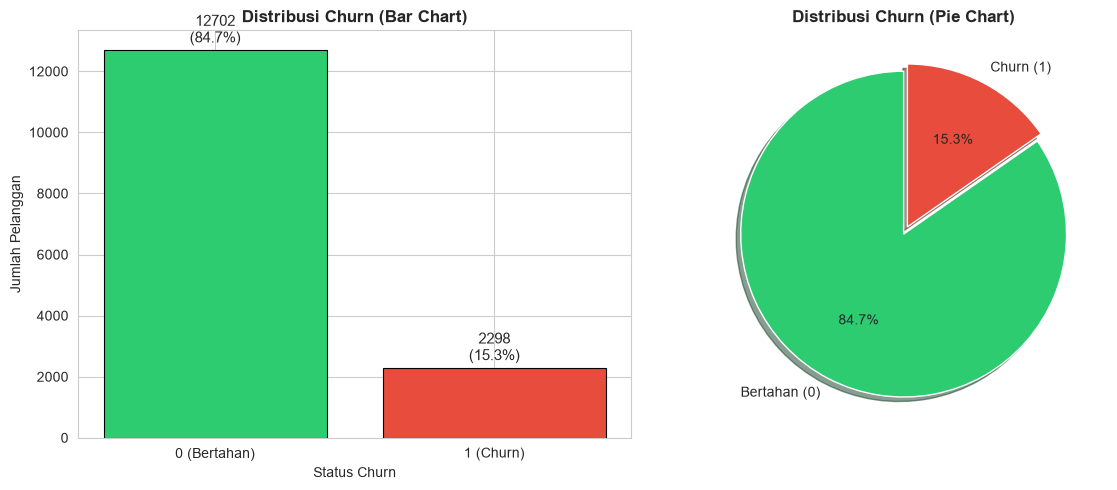

In [10]:
# Visualisasi distribusi target dengan countplot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
ax1 = axes[0]
churn_counts = df['churn'].value_counts()
bars = ax1.bar(churn_counts.index.astype(str), churn_counts.values,
               color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=0.8)

for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 100,
             f'{int(height)}\n({height/len(df)*100:.1f}%)',
             ha='center', va='bottom', fontsize=11)

ax1.set_xlabel('Status Churn')
ax1.set_ylabel('Jumlah Pelanggan')
ax1.set_title('Distribusi Churn (Bar Chart)', fontsize=12, fontweight='bold')
ax1.set_xticks([0, 1])
ax1.set_xticklabels(['0 (Bertahan)', '1 (Churn)'])

# Pie chart
ax2 = axes[1]
ax2.pie(churn_counts.values, labels=['Bertahan (0)', 'Churn (1)'],
        autopct='%1.1f%%', startangle=90,
        colors=['#2ecc71', '#e74c3c'],
        explode=(0, 0.05), shadow=True)
ax2.set_title('Distribusi Churn (Pie Chart)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

**Insight:**
- Dataset menunjukkan ketidakseimbangan kelas (class imbalance) yang cukup signifikan.
- Pelanggan yang bertahan (0) mendominasi sebesar ~84.68% (12.702 data).
- Pelanggan yang churn (1) hanya ~15.32% (2.298 data).
- Ketidakseimbangan ini perlu diperhatikan saat pemodelan nanti, bisa menggunakan teknik seperti SMOTE, class_weight, atau stratified sampling agar model tidak bias ke kelas mayoritas.

## 5. Heatmap Korelasi Fitur Numerik

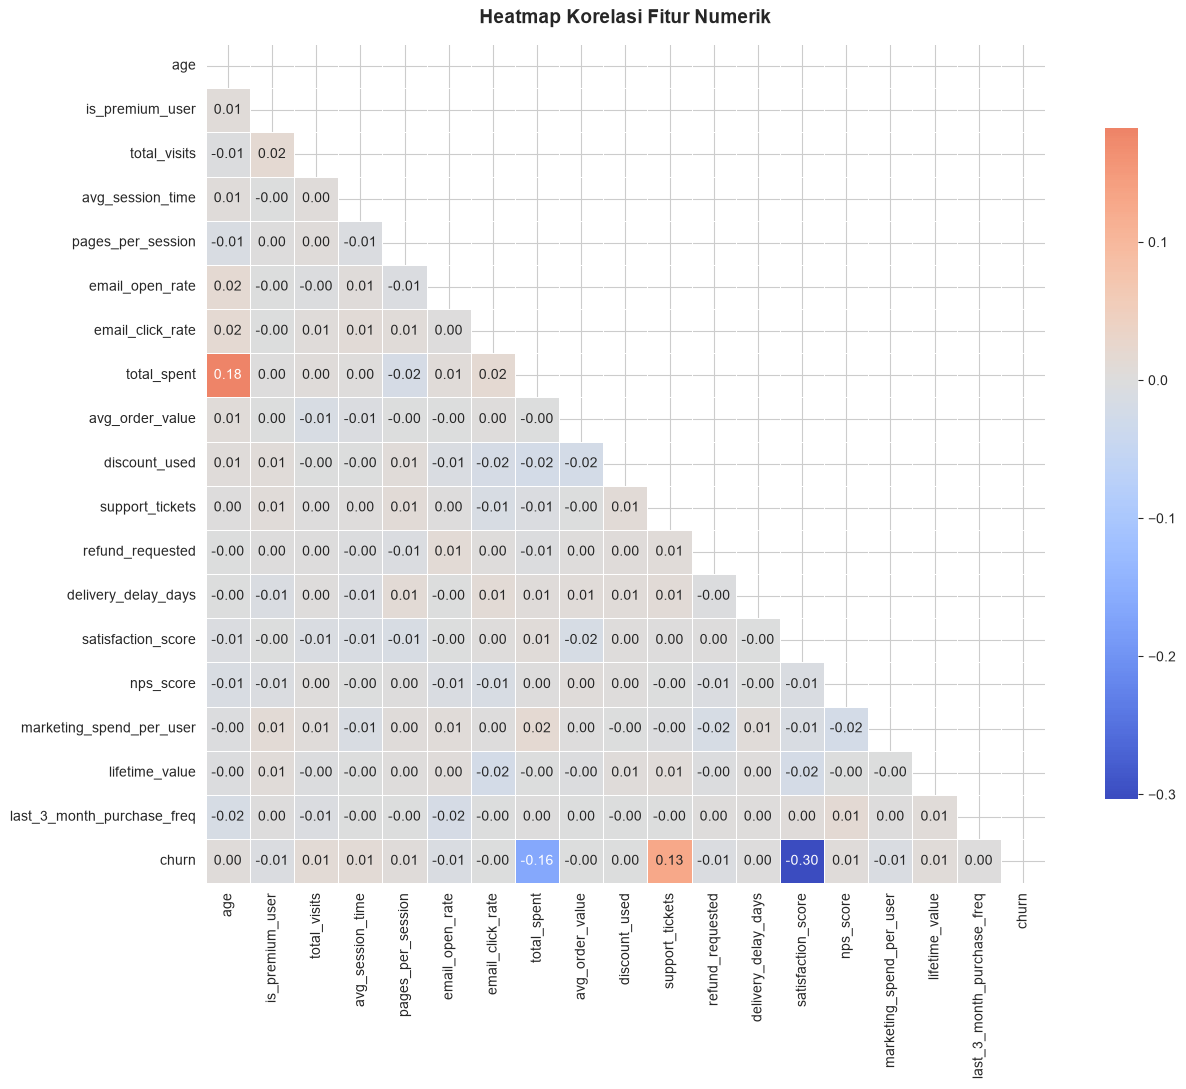

In [11]:
# ============================================================
# TUGAS 4: Heatmap korelasi fitur numerik
# ------------------------------------------------------------
# corr() -> korelasi Pearson antar fitur numerik.
# customer_id dibuang karena cuma ID (bukan fitur prediktif).
# mask segitiga atas supaya heatmap tidak menampilkan nilai kembar.
# ============================================================
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
numeric_cols.remove('customer_id')  # buang ID, bukan fitur prediktif

# Hitung matriks korelasi
corr_matrix = df[numeric_cols].corr()

# Visualisasi heatmap
plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # mask segitiga atas biar ga redundan

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            square=True, cbar_kws={'shrink': 0.8})

plt.title('Heatmap Korelasi Fitur Numerik', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [12]:
# Korelasi masing-masing fitur terhadap target churn, diurutkan
corr_with_churn = df[numeric_cols].corr()['churn'].drop('churn').sort_values(ascending=False)

print('=== Korelasi Fitur Numerik terhadap Churn ===')
print(corr_with_churn.to_string())

=== Korelasi Fitur Numerik terhadap Churn ===
support_tickets               0.127910
total_visits                  0.013212
avg_session_time              0.012198
lifetime_value                0.006250
pages_per_session             0.005871
nps_score                     0.005749
age                           0.004506
delivery_delay_days           0.001603
last_3_month_purchase_freq    0.001590
discount_used                 0.000265
avg_order_value              -0.001480
email_click_rate             -0.001752
is_premium_user              -0.005496
refund_requested             -0.006959
marketing_spend_per_user     -0.007315
email_open_rate              -0.008439
total_spent                  -0.163279
satisfaction_score           -0.303588


**Insight:**
- Secara umum, mayoritas fitur numerik memiliki korelasi linear yang lemah satu sama lain (mendekati 0).
- Terhadap variabel target `churn`, beberapa hubungan yang menonjol:
  - `satisfaction_score` memiliki korelasi negatif paling kuat (~-0.30), artinya semakin rendah kepuasan pelanggan, semakin besar kemungkinan churn.
  - `support_tickets` berkorelasi positif (~0.13), menunjukkan pelanggan yang sering komplain lebih rentan churn.
  - `total_spent` berkorelasi negatif (~-0.16), pelanggan yang banyak belanja cenderung lebih loyal.
- Tidak ada multikolinearitas yang parah antar fitur prediktor, sehingga sebagian besar fitur bisa digunakan bersamaan tanpa masalah redundansi.

---
## Kesimpulan EDA

1. Dataset memiliki 15.000 baris dan 30 kolom dengan variasi tipe data (numerik, kategorikal, biner, ordinal).
2. Terdapat 5 kolom dengan missing value, yang terbesar adalah `coupon_code` (40.89%).
3. Distribusi target menunjukkan class imbalance: 84.68% bertahan vs 15.32% churn.
4. Fitur `satisfaction_score`, `support_tickets`, dan `total_spent` memiliki korelasi paling signifikan terhadap churn.
5. Langkah selanjutnya: penanganan missing value, encoding fitur kategorikal, dan penanganan class imbalance sebelum pemodelan.